In [2]:
#import_labraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [4]:
#import_data

In [5]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
            Select name
            from sqlite_master
            where type = 'table'
            
"""

tables = pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"Select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created Dataframe: df_{table_name}")

conn.close()


Created Dataframe: df_db_customer
Created Dataframe: df_db_subscription
Created Dataframe: df_db_support


In [6]:
#data_cleaning

In [7]:
# customer table
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [8]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [9]:
# a. rename col - name
# b. drop columnns - intersets and  pincode
# c. change data type  - dob
# d. data standardization - gender
# e. fix missing values - country

In [10]:
# a. rename col - name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [11]:
# b. drop columnns - intersets and  pincode
# df_db_customer.columns[-2:]
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)
df_db_customer.drop(columns = ['interests', 'pincode'], inplace=True)

In [12]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [13]:
# c. change data type  - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [16]:
# d. data standardization - gender
# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women' : 'Female'})

In [28]:
# e. fix missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [29]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [27]:
# country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [30]:
# subscription table
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [34]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [36]:
# support table
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [37]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [38]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [40]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [41]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [ ]:
# 3. Feature Engineering and Data Analysis

In [43]:
# create a new col using exiting col - chrun flag
df_db_subscription['chrun_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [44]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,chrun_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [46]:
# first fix support table duplicates then merge 
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [50]:
df_db_subscription.shape

(21, 12)

In [47]:
df.shape

(23, 20)

In [51]:
df_db_subscription['customerid'].nunique()

21

In [52]:
df_db_customer['customerid'].nunique()

21

In [53]:
df_db_support['customerid'].nunique()

7

In [54]:
df_db_support['customerid'].size

9

In [55]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [58]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [62]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [63]:
df_db_support['customerid'].size

7

In [64]:
# merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [65]:
df.shape

(21, 21)

In [66]:
df.to_csv('exported_chrun_data.csv', index=False)

In [ ]:
# Data analysis

In [ ]:
# 1. chrun data

In [67]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'chrun_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [91]:
churn_rate = df['chrun_flag'].mean()*100
print("Churn rate = ", round(churn_rate, 2), '%')

Churn rate =  28.57 %


In [92]:
# 2. Rentenion Rate
rentenion_rate = 100 - churn_rate
print("Retention Rate = ", round(rentenion_rate, 2), '%')

Retention Rate =  71.43 %


In [93]:
df['plan_type'].unique()

<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [94]:
# 3. Churn by Plan type
churn_by_plan = df.groupby('plan_type')['chrun_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [103]:
#  4 a. Churn by state + sum(revenue) and count of user 
churn_by_state = df.groupby('state')['chrun_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_state')
churn_by_state

,state,churn_rate_state
0,Delhi,25.00
1,Karnataka,100.00
2,Kathmandu,0.00
3,Maharashtra,0.00
4,Meghalaya,66.67
5,Nagaland,0.00
6,Rajasthan,0.00
7,Telangana,50.00
8,Uttar Pradesh,0.00


In [104]:
# 4 b. Churn by subscription type + sum(revenue) and count of users
churn_by_subscription = df.groupby('subscription_type')['chrun_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_state')
churn_by_subscription

,subscription_type,churn_rate_state
0,Organic,0.00
1,Paid,16.67
2,Refferal,83.33


In [105]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'chrun_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [107]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print("ARPU = ", round(arpu, 2))

ARPU =  18.85


In [114]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure))

Avg Tenure (Days) =  1522


In [130]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['chrun_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk(Rs 'k') = ", revenue_at_risk)

Revenue at Risk(Rs 'k') =  73.94


In [135]:
# 8. Esclation rate
escalations_rate = (df['escalations']=='Y').mean()*100
print("Escalations Rate = ", round(escalations_rate, 2), "%")

Escalations Rate =  19.05 %


In [140]:
# 9. Aug Complaint Per User
avg_complaint = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants per User = ", round(avg_complaint, 2))

Avg Compliants per User =  0.43


In [160]:
# 10. Correlation Esclation vs Churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'chrun_flag']].dropna()

correlation = corr_df['escalations'].corr(df['chrun_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  nan


In [163]:
# 11. churn rsik - create a column using existing col
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [166]:
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_rsik'] = np.select(conditions, choices, default='unkown')

In [169]:
df[['churn_rsik', 'churn_score']].tail()

,churn_rsik,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [170]:
# 4. Visualization using Matplotlib

In [171]:
df_visual = df.copy()

In [173]:
df_visual.shape

(21, 23)

In [181]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'chrun_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_rsik'],
      dtype='str')

In [ ]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

<BarContainer object of 3 artists>

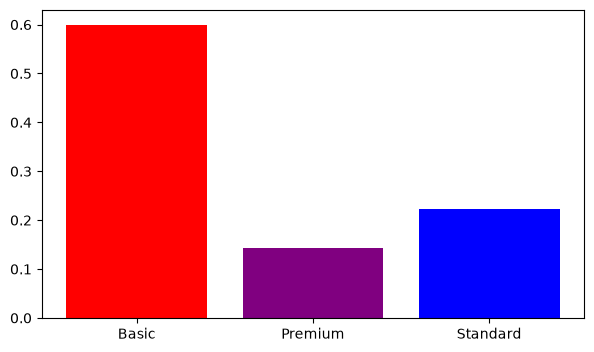

In [190]:
# 4.2 churn by plan type
churn_plan = df_visual.groupby('plan_type')['chrun_flag'].mean()

colors = ['red', 'purple', 'blue']

plt.figure(figsize = (7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

<BarContainer object of 9 artists>

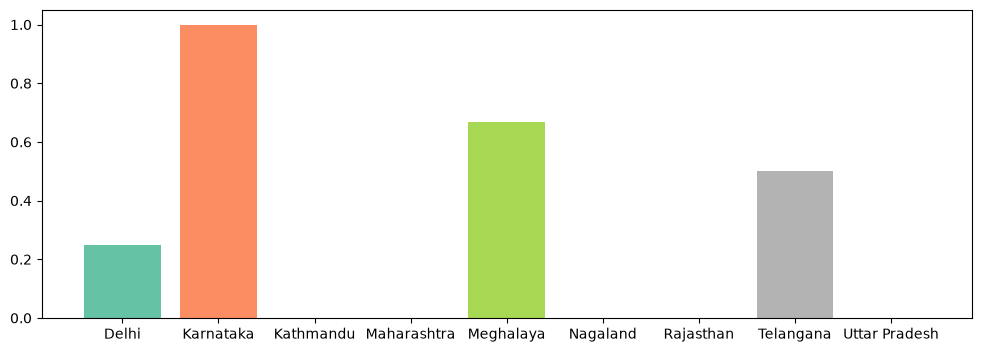

In [196]:
# 4.3 churn by states 
churn_plan = df_visual.groupby('state')['chrun_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize = (12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

In [ ]:
# visualtion using Seaborn

In [205]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'chrun_flag', 'churn_rsik', 'escalations']].head()


,plan_type,contract_type,churn_score,chrun_flag,churn_rsik,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [206]:
df_encoded.tail()

,plan_type,contract_type,churn_score,chrun_flag,churn_rsik,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,0


In [203]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'chrun_flag', 'churn_rsik', 'escalations']].head()

categorial_cols = ['plan_type', 'contract_type', 'churn_rsik']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

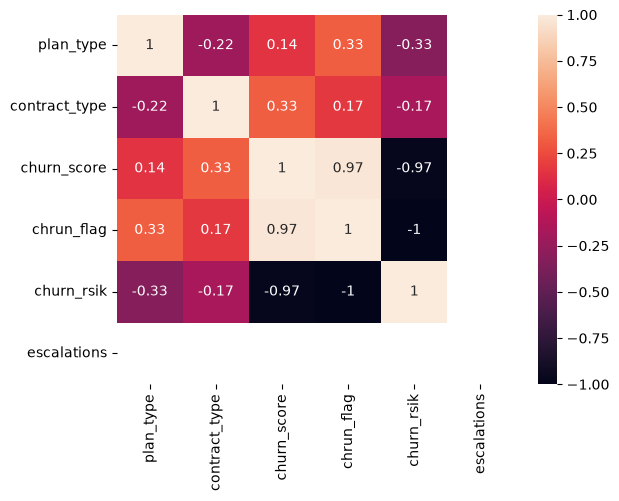

In [207]:
# heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)